## Kenya E-commerce & Delivery Performance Analytics

### Business Problem 

The e-commerce company lacks a clear understanding of how geographic location, courier performance, and delivery characteristics affect operational performance and customer experience.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
data = pd.read_csv("messy_kenya_ecommerce_large.csv")


In [73]:
data.head()

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
0,KE-10001,CUST-5327,NaN,Mombasa,Fashion & Apparel,22674.0,NaN,Pickup Station,G4S,35kg,353,6.0,Cancelled,3.0
1,KE-10002,CUST-5414,2025-01-04,kiambu,Fashion & Apparel,11529.0,Cash on Delivery,Home Delivery,DHL,16.13,537,3.0,Delivered,5.0
2,KE-10003,CUST-5098,2025-12-27,Mombasa,Health & Wellness,3809.0,m-pesa,Pickup Station,DHL,9.42,223,2.0,Delayed,4.0
3,KE-10004,CUST-5138,2025-11-24,Kiambu,Health & Wellness,1551.0,Credit/Debit Card,Smart Locker,G4S,22.97,619,2.0,Delivered,NaN
4,KE-10005,CUST-5299,2025-08-08,Mombasa,Fashion & Apparel,3478.0,m-pesa,Boda Boda Last-Mile,Local Rider,2.32,629,NaN,Returned,1.0


In [74]:
data.tail()

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
995,KE-10996,CUST-5481,2025-12-24,Kiambu,Beauty,2322.0,M-Pesa,Boda Boda Last-Mile,Chui Lockers,15.04,254,3.0,Delivered,5.0
996,KE-10997,CUST-5481,2025-10-07,Nairobi,Health & Wellness,-17996,COD,Pickup Station,DHL,32.74,568,5.0,Delayed,2.0
997,KE-10998,CUST-5387,2025-11-30,Mombasa,Electronics,10571.0,m-pesa,Pickup Station,Chui Lockers,23.15,564,1.0,Returned,2.0
998,KE-10999,CUST-5037,2025-09-12,Mombasa,Health & Wellness,22233.0,Credit/Debit Card,Home Delivery,Local Rider,7.02,365,2.0,Delivered,3.0
999,KE-11000,CUST-5140,2025-08-18,Mombasa,Electronics,18015.0,M-Pesa,Home Delivery,DHL,29.31,228,5.0,Delivered,NaN


In [75]:
data.shape

(1000, 14)

In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            1000 non-null   object 
 1   Customer_ID         1000 non-null   object 
 2   Order_Date          964 non-null    object 
 3   Customer_County     972 non-null    object 
 4   Product_Category    1000 non-null   object 
 5   Order_Value_KES     971 non-null    object 
 6   Payment_Method      966 non-null    object 
 7   Delivery_Method     1000 non-null   object 
 8   Courier_Partner     1000 non-null   object 
 9   Package_Weight_Kg   1000 non-null   object 
 10  Shipping_Fee_KES    1000 non-null   int64  
 11  Transit_Time_Days   952 non-null    float64
 12  Fulfillment_Status  1000 non-null   object 
 13  Customer_Rating     848 non-null    float64
dtypes: float64(2), int64(1), object(11)
memory usage: 109.5+ KB


In [77]:
data = data.map(lambda x: x.strip() if isinstance(x, str) else x)


In [78]:
data[data.duplicated(keep= False)]


,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating


In [79]:
data["Order_Date"].head(20
                    )

0            NaN
1     2025-01-04
2     2025-12-27
3     2025-11-24
4     2025-08-08
5     2025-10-02
6     2025-06-15
7     2025-10-04
8     2025-05-23
9     2025-04-09
10    2025-01-02
11    2025-04-06
12    2025-08-23
13    2025-03-01
14    2025-10-10
15    2025-07-28
16    2025-08-24
17    2025-11-02
18    2025-12-08
19    2025-03-28
Name: Order_Date, dtype: object

In [80]:
dates = data["Order_Date"].str.strip()
dates[dates.notna()  & ~dates.str.fullmatch(r"\d{4}-\d{2}-\d{2}", na=False)
]

20     17/03/2025
30     04/07/2025
67     15/03/2025
98     24/04/2025
198    24/08/2025
249    10/12/2025
326    01/08/2025
328    10/06/2025
422    10/02/2025
442    24/03/2025
508    31/08/2025
561    12/04/2025
668    07/10/2025
670    04/03/2025
759    23/12/2025
788    23/01/2025
980    13/12/2025
986    08/02/2025
Name: Order_Date, dtype: object

In [81]:
hyphen_dates = pd.to_datetime(
    dates,
    format="%Y-%m-%d",
    errors="coerce"
)

In [82]:
slash_dates = pd.to_datetime(
    dates,
    format="%d/%m/%Y",
    errors="coerce"
)

In [83]:
clean_dates = hyphen_dates.fillna(slash_dates) #keep converted hyphen date where missing use converted slash date


In [84]:
dates[dates.notna() & clean_dates.isna()]

Series([], Name: Order_Date, dtype: object)

In [85]:
data["Order_Date"] = clean_dates

In [86]:
data["Order_Date"].dtype


dtype('<M8[ns]')

In [87]:
data["Order_Date"].head()

0          NaT
1   2025-01-04
2   2025-12-27
3   2025-11-24
4   2025-08-08
Name: Order_Date, dtype: datetime64[ns]

In [88]:

data["Customer_County"].value_counts()



Customer_County
Mombasa           169
nairobi           101
kiambu             92
Machakos           85
Kajiado            82
Kiambu             78
Uasin Gishu        77
Nairobi County     76
Nairobi            76
Nakuru             71
Kisumu             65
Name: count, dtype: int64

In [118]:

data["Customer_County"] = data["Customer_County"].str.title()
data["Customer_County"] = data["Customer_County"].replace({'Nairobi County': 'Nairobi'
                                                          })


In [119]:

data["Customer_County"].value_counts()

Customer_County
Nairobi        253
Kiambu         170
Mombasa        169
Machakos        85
Kajiado         82
Uasin Gishu     77
Nakuru          71
Kisumu          65
Name: count, dtype: int64

In [120]:
data['Product_Category'].value_counts()

Product_Category
Electronics          181
Home & Living        157
Beauty               153
Fashion & Apparel    142
Health & Wellness    139
Groceries            126
Fashion              102
Name: count, dtype: int64

In [121]:
data['Product_Category']=data['Product_Category'].str.title()
data['Product_Category']= data["Product_Category"].replace({'Electrnics':'Electronics'})


In [122]:
data['Product_Category'].value_counts()

Product_Category
Electronics          181
Home & Living        157
Beauty               153
Fashion & Apparel    142
Health & Wellness    139
Groceries            126
Fashion              102
Name: count, dtype: int64

In [123]:
data["Order_Value_KES"].dtype

dtype('float64')

In [124]:
data['Order_Value_KES'].value_counts().head(20) #show the top most 20 unique values and their frequencies

Order_Value_KES
19795.0    3
19870.0    2
16919.0    2
18091.0    2
15973.0    2
5926.0     2
9204.0     2
4193.0     2
10795.0    2
23215.0    2
10346.0    2
20715.0    2
22236.0    2
20469.0    2
22798.0    2
3374.0     2
21866.0    2
19024.0    2
18577.0    2
17503.0    2
Name: count, dtype: int64

In [125]:
data["Order_Value_KES"].str.contains('-',na=False).sum() ## negative value rows

AttributeError: Can only use .str accessor with string values!

In [126]:
# Remove 'KSh', commas, and whitespace, then convert to numeric float
data['Order_Value_KES'] = data['Order_Value_KES'].astype(str).str.replace(r'[KSh,\s]', '', regex=True)
data['Order_Value_KES'] = pd.to_numeric(data['Order_Value_KES'], errors='coerce')


In [127]:
data['Order_Value_KES'].dtype

dtype('float64')

In [128]:
data["Negative_Order_Value"]=data['Order_Value_KES']<0

In [129]:
data

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating,Negative_Order_Value,Order_Value_For_Analysis,Unresolved_Transit_Time,Transit_Time_For_Analysis
0,KE-10001,CUST-5327,NaT,Mombasa,Fashion & Apparel,22674.0,NaN,Pickup Station,G4S,35.00,353,6.0,Cancelled,3.0,False,22674.0,False,6.0
1,KE-10002,CUST-5414,2025-01-04,Kiambu,Fashion & Apparel,11529.0,Cash on Delivery,Home Delivery,DHL,16.13,537,3.0,Delivered,5.0,False,11529.0,False,3.0
2,KE-10003,CUST-5098,2025-12-27,Mombasa,Health & Wellness,3809.0,M-Pesa,Pickup Station,DHL,9.42,223,2.0,Delayed,4.0,False,3809.0,False,2.0
3,KE-10004,CUST-5138,2025-11-24,Kiambu,Health & Wellness,1551.0,Credit/Debit Card,Smart Locker,G4S,22.97,619,2.0,Delivered,NaN,False,1551.0,False,2.0
4,KE-10005,CUST-5299,2025-08-08,Mombasa,Fashion & Apparel,3478.0,M-Pesa,Boda Boda Last-Mile,Local Rider,2.32,629,NaN,Returned,1.0,False,3478.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,KE-10996,CUST-5481,2025-12-24,Kiambu,Beauty,2322.0,M-Pesa,Boda Boda Last-Mile,Chui Lockers,15.04,254,3.0,Delivered,5.0,False,2322.0,False,3.0
996,KE-10997,CUST-5481,2025-10-07,Nairobi,Health & Wellness,-17996.0,Cash on Delivery,Pickup Station,DHL,32.74,568,5.0,Delayed,2.0,True,NaN,False,5.0
997,KE-10998,CUST-5387,2025-11-30,Mombasa,Electronics,10571.0,M-Pesa,Pickup Station,Chui Lockers,23.15,564,1.0,Returned,2.0,False,10571.0,False,1.0
998,KE-10999,CUST-5037,2025-09-12,Mombasa,Health & Wellness,22233.0,Credit/Debit Card,Home Delivery,Local Rider,7.02,365,2.0,Delivered,3.0,False,22233.0,False,2.0


In [130]:
data.loc[
    data["Negative_Order_Value"],
    ["Order_ID", "Order_Value_KES", "Fulfillment_Status"]
]

,Order_ID,Order_Value_KES,Fulfillment_Status
188,KE-10189,-20274.0,Returned
192,KE-10193,-21481.0,Delivered
195,KE-10196,-12070.0,Cancelled
223,KE-10224,-15735.0,Delivered
411,KE-10412,-7637.0,Delivered
528,KE-10529,-22723.0,Delivered
566,KE-10567,-9526.0,Delivered
587,KE-10588,-9433.0,Delivered
626,KE-10627,-17525.0,Cancelled
696,KE-10697,-12135.0,Delivered


negatives are spread across several statuses, so being returned cannot explain all of them. A delivered order could still have a refund or adjustment, but these columns don’t confirm that.

In [131]:
data["Order_Value_For_Analysis"] = data["Order_Value_KES"].where(
    ~data["Negative_Order_Value"]
)

In [132]:
data.loc[
    data["Negative_Order_Value"],
    ["Order_Value_KES", "Order_Value_For_Analysis"]
]

,Order_Value_KES,Order_Value_For_Analysis
188,-20274.0,NaN
192,-21481.0,NaN
195,-12070.0,NaN
223,-15735.0,NaN
411,-7637.0,NaN
528,-22723.0,NaN
566,-9526.0,NaN
587,-9433.0,NaN
626,-17525.0,NaN
696,-12135.0,NaN


In [133]:
data["Payment_Method"].value_counts()

Payment_Method
Cash on Delivery     384
M-Pesa               383
Credit/Debit Card    199
Name: count, dtype: int64

In [134]:
data["Payment_Method"]= data["Payment_Method"].replace(
    {
        'm-pesa': 'M-Pesa',
        'COD': 'Cash on Delivery'
    }
)

In [135]:
data['Courier_Partner'].value_counts()

Courier_Partner
Wells Fargo     178
G4S             173
Chui Lockers    173
DHL             165
Local Rider     163
Sendy           148
Name: count, dtype: int64

In [136]:
data["Shipping_Fee_KES"].value_counts().head(20)

Shipping_Fee_KES
0      54
564     6
646     5
549     5
214     5
624     5
715     5
471     5
228     5
783     5
757     4
714     4
640     4
342     4
666     4
515     4
745     4
546     4
532     4
637     4
Name: count, dtype: int64

In [137]:
data['Transit_Time_Days'].dtype


dtype('float64')

In [138]:
data['Transit_Time_Days'].describe()

count    952.000000
mean      16.410714
std      111.096137
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max      999.000000
Name: Transit_Time_Days, dtype: float64

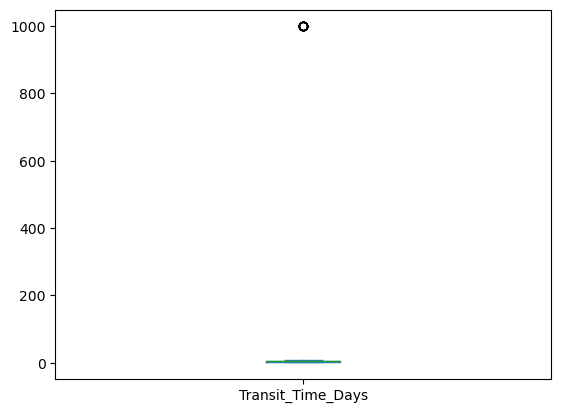

In [139]:
data['Transit_Time_Days'].plot(kind='box')
plt.show()

In [140]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['Transit_Time_Days'].quantile(0.25)
Q3 = data['Transit_Time_Days'].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Define the upper boundary line
upper_boundary = Q3 + (1.5 * IQR)

print(f"The middle 50% of deliveries take between {Q1} and {Q3} days.")
print(f"Any delivery taking more than {upper_boundary} days is mathematically an outlier.")



The middle 50% of deliveries take between 2.0 and 6.0 days.
Any delivery taking more than 12.0 days is mathematically an outlier.


In [141]:
data.shape

(1000, 18)

In [142]:
data.loc[
    data["Transit_Time_Days"] > upper_boundary,
    ["Order_ID", "Transit_Time_Days", "Fulfillment_Status", "Courier_Partner"]
]

,Order_ID,Transit_Time_Days,Fulfillment_Status,Courier_Partner
216,KE-10217,999.0,Delivered,DHL
222,KE-10223,999.0,Cancelled,Local Rider
339,KE-10340,999.0,Delayed,Sendy
475,KE-10476,999.0,Returned,DHL
487,KE-10488,999.0,Delivered,Local Rider
600,KE-10601,999.0,Delayed,Local Rider
620,KE-10621,999.0,Delivered,Sendy
651,KE-10652,999.0,Delayed,Chui Lockers
672,KE-10673,999.0,Returned,G4S
757,KE-10758,999.0,Delivered,Wells Fargo


In [143]:
data["Unresolved_Transit_Time"] = data["Transit_Time_Days"].eq(999)

data["Transit_Time_For_Analysis"] = data["Transit_Time_Days"].where(
    ~data["Unresolved_Transit_Time"]
)

In [144]:
data['Transit_Time_Days'].describe()

count    952.000000
mean      16.410714
std      111.096137
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max      999.000000
Name: Transit_Time_Days, dtype: float64

In [145]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Order_ID                   1000 non-null   object        
 1   Customer_ID                1000 non-null   object        
 2   Order_Date                 964 non-null    datetime64[ns]
 3   Customer_County            972 non-null    object        
 4   Product_Category           1000 non-null   object        
 5   Order_Value_KES            971 non-null    float64       
 6   Payment_Method             966 non-null    object        
 7   Delivery_Method            1000 non-null   object        
 8   Courier_Partner            1000 non-null   object        
 9   Package_Weight_Kg          1000 non-null   float64       
 10  Shipping_Fee_KES           1000 non-null   int64         
 11  Transit_Time_Days          952 non-null    float64       
 12  Fulfill

In [146]:
data['Package_Weight_Kg'].value_counts().head(20)

Package_Weight_Kg
35.00    29
26.49     4
34.34     3
3.54      3
16.71     3
29.62     3
5.08      3
3.01      3
33.24     3
12.15     3
19.92     3
12.63     3
5.93      3
25.55     3
10.54     3
27.60     3
1.79      3
16.62     3
30.92     2
32.12     2
Name: count, dtype: int64

In [147]:
data['Package_Weight_Kg'] = (
    data['Package_Weight_Kg']
    .astype(str)
    .str.replace(r'(?i)\s*kg|\s*k', '', regex=True)
    .str.replace(',', '', regex=False)
    .str.strip()
)

data['Package_Weight_Kg'] = pd.to_numeric(
    data['Package_Weight_Kg'], 
    errors='coerce'
)

In [148]:
data.loc[
    data.duplicated(subset=["Order_ID"], keep=False)
].sort_values("Order_ID")

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating,Negative_Order_Value,Order_Value_For_Analysis,Unresolved_Transit_Time,Transit_Time_For_Analysis
13,KE-10014,CUST-5135,2025-03-01,Nairobi,Home & Living,11735.0,Cash on Delivery,Home Delivery,Sendy,22.24,0,7.0,Delivered,NaN,False,11735.0,False,7.0
14,KE-10014,CUST-5226,2025-10-10,Nairobi,Beauty,18377.0,Cash on Delivery,Pickup Station,Chui Lockers,4.55,190,2.0,Delivered,5.0,False,18377.0,False,2.0
40,KE-10041,CUST-5436,2025-06-18,Kiambu,Beauty,16489.0,Cash on Delivery,Home Delivery,Chui Lockers,34.24,252,NaN,Delivered,1.0,False,16489.0,False,NaN
41,KE-10041,CUST-5150,2025-07-03,Nakuru,Beauty,6070.0,M-Pesa,Pickup Station,G4S,16.19,411,7.0,Cancelled,2.0,False,6070.0,False,7.0
103,KE-10104,CUST-5459,2025-10-04,Nairobi,Beauty,16909.0,M-Pesa,Smart Locker,Local Rider,26.94,556,3.0,Delayed,4.0,False,16909.0,False,3.0
104,KE-10104,CUST-5116,2025-07-02,Nairobi,Beauty,20770.0,Cash on Delivery,Pickup Station,DHL,13.70,0,3.0,Delivered,2.0,False,20770.0,False,3.0
310,KE-10311,CUST-5154,2025-07-22,Nakuru,Fashion & Apparel,17006.0,M-Pesa,Boda Boda Last-Mile,G4S,9.19,280,7.0,Delayed,3.0,False,17006.0,False,7.0
311,KE-10311,CUST-5462,2025-05-15,Mombasa,Groceries,10839.0,Credit/Debit Card,Boda Boda Last-Mile,Sendy,6.69,0,3.0,Delivered,4.0,False,10839.0,False,3.0
548,KE-10549,CUST-5127,2025-05-24,Nairobi,Beauty,18125.0,M-Pesa,Home Delivery,Wells Fargo,34.20,305,5.0,Delivered,4.0,False,18125.0,False,5.0
549,KE-10549,CUST-5125,2025-06-17,Mombasa,Health & Wellness,1216.0,Cash on Delivery,Smart Locker,Chui Lockers,26.18,478,4.0,Returned,3.0,False,1216.0,False,4.0


In [149]:
data["Repeated_Order_ID"] = data.duplicated(
  subset=["Order_ID"], keep=False
    
)

In [152]:
pd.crosstab(data['Delivery_Method'],data["Shipping_Fee_KES"].eq(0))


Shipping_Fee_KES,False,True
Delivery_Method,,
Boda Boda Last-Mile,241,15
Home Delivery,237,12
Pickup Station,240,13
Smart Locker,228,14


Do zero-fee orders tend to have higher order values than orders with a shipping fee?

In [159]:
data.loc [
    data["Shipping_Fee_KES"].eq(0),
    ["Shipping_Fee_KES", "Order_Value_For_Analysis"]
]

,Shipping_Fee_KES,Order_Value_For_Analysis
12,0,4840.0
13,0,11735.0
38,0,18585.0
42,0,15469.0
48,0,20029.0
62,0,11697.0
68,0,18391.0
104,0,20770.0
109,0,12281.0
140,0,22455.0


In [162]:
data.groupby(
    data["Shipping_Fee_KES"].eq(0)
)["Order_Value_For_Analysis"].agg(["count", "mean", "median"])
Free_delivery

,count,mean,median
Shipping_Fee_KES,,,
False,900,12775.928889,12799.5
True,52,13920.076923,14040.5


In [168]:
data.loc[
    data["Shipping_Fee_KES"].eq(0),
    "Order_Value_For_Analysis"
].agg(["min", "max"])

min     1606.0
max    24084.0
Name: Order_Value_For_Analysis, dtype: float64

free shipping occurs for both relatively low and high order values. The higher average doesn’t mean free shipping is limited to high-value orders.

For example, a rule saying “free shipping only above KES 10,000” would not explain the KES 1,606 order without an exception.

In [169]:
data.groupby(
    data["Shipping_Fee_KES"].eq(0)
)["Order_Value_For_Analysis"].agg(["min", "max"])

,min,max
Shipping_Fee_KES,,
False,535.0,24953.0
True,1606.0,24084.0


### Business Questions

Q1- Geographic Performance
How does e-commerce performance vary across Kenyan counties in terms of order volume, revenue, and delivery time?

Q2 — Courier performance

Which courier partners and delivery methods provide the best balance of delivery speed, fulfillment performance, and customer satisfaction?

Q3 — Delivery economics

How do package weight, shipping fees, and delivery time relate to each other?

Q4 — Customer experience

To what extent is delivery performance associated with customer satisfaction?

In [172]:
county_summary = data.groupby("Customer_County").agg(
    Order_Records=("Order_ID", "size"),
    Total_Order_Value_KES=("Order_Value_For_Analysis", "sum"),
    Average_Transit_Days=("Transit_Time_For_Analysis", "mean")
)

county_summary

,Order_Records,Total_Order_Value_KES,Average_Transit_Days
Customer_County,,,
Kajiado,82,1019897.0,3.480519
Kiambu,170,1986635.0,4.012739
Kisumu,65,832716.0,3.515625
Machakos,85,1005406.0,3.777778
Mombasa,169,2117734.0,3.820513
Nairobi,253,3112741.0,3.890295
Nakuru,71,872803.0,3.855072
Uasin Gishu,77,900144.0,4.405405


Nairobi has the highest number of order records (253) and the highest total usable recorded order value (KES 3,112,741) among counties in the dataset.

could Nairobi’s higher total order value simply be because it has more orders?

In [173]:
data.groupby('Customer_County')['Order_Value_For_Analysis'].mean()

Customer_County
Kajiado        12748.712500
Kiambu         12040.212121
Kisumu         13217.714286
Machakos       12567.575000
Mombasa        13153.627329
Nairobi        12969.754167
Nakuru         13637.546875
Uasin Gishu    12502.000000
Name: Order_Value_For_Analysis, dtype: float64

Nairobi leads in order volume and total recorded order value, while Nakuru has the highest average usable order value.

In [177]:
data.loc[
    data["Customer_County"].eq("Uasin Gishu")
].groupby("Delivery_Method")["Transit_Time_For_Analysis"].agg(
    ["count", "mean"]
)

,count,mean
Delivery_Method,,
Boda Boda Last-Mile,26,4.461538
Home Delivery,19,3.947368
Pickup Station,14,5.642857
Smart Locker,15,3.733333


Within Uasin Gishu, pickup-station orders had the longest average transit time at 5.64 days, compared with 3.73 days for smart-locker orders.